# 05 - Learner Segmentation and Personalized Recommendation

This notebook turns the engineered day-30 feature store into two deliverables for **Part I** of the final project:

1. **Learner segmentation** with both an interpretable rule-based baseline and a data-driven K-Means solution.
2. **Personalized learning path recommendations** grounded in successful peer behavior, early engagement fit, assessment discipline, and module-level activity availability.

**Project role in the pipeline**
- Input: processed outputs from notebooks `02`, `03`, and `04`
- Output: segment assignments, cluster profiles, cluster success activity profiles, and enrollment-level personalized learning path recommendations
- Downstream use: Power BI storytelling and business interpretation before moving to notebook `06_at_risk_modeling.ipynb`


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*matmul.*')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*current_pot.*')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 11


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root.')


ROOT = find_repo_root()
PROCESSED = ROOT / 'data' / 'processed'
NOTEBOOKS = ROOT / 'notebooks'

KEY = ['id_student', 'code_module', 'code_presentation']
OUTCOME_ORDER = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
SUCCESS_OUTCOMES = {'Pass', 'Distinction'}
SEG_FEATURES = [
    'total_clicks_log',
    'active_days_log',
    'early_engagement_log',
    'early_engagement_ratio',
    'avg_score',
    'score_std',
    'engagement_intensity_log',
    'assessment_discipline',
    'persistence_score',
    'completion_ratio',
]
REC_FEATURES = [
    'total_clicks_log',
    'early_engagement_ratio',
    'engagement_intensity_log',
    'avg_score',
    'completion_ratio',
    'assessment_discipline',
    'persistence_score',
    'learning_risk_index',
]
CLUSTER_ORDER = [
    'Inactive Drop-offs',
    'Sporadic Explorers',
    'Steady Progressors',
    'Focused Achievers',
]
ACTIVITY_LABEL_MAP = {
    'oucontent': 'Core learning content',
    'quiz': 'Self-check quizzes',
    'forumng': 'Discussion forum',
    'homepage': 'Course homepage',
    'subpage': 'Structured topic pages',
    'resource': 'Downloadable resources',
    'ouwiki': 'Collaborative wiki',
    'page': 'Static pages',
    'url': 'External links',
    'questionnaire': 'Questionnaires',
    'oucollaborate': 'Collaboration spaces',
    'externalquiz': 'External quizzes',
    'glossary': 'Glossary',
    'dataplus': 'Data tools',
    'ouelluminate': 'Live sessions',
}


def humanize_activity_type(activity_type: str) -> str:
    if pd.isna(activity_type):
        return np.nan
    return ACTIVITY_LABEL_MAP.get(activity_type, activity_type.replace('_', ' ').title())


print(f'Repository root: {ROOT}')
print(f'Processed data directory: {PROCESSED}')


Repository root: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project
Processed data directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project/data/processed


## 1. Load the processed feature store

The segmentation and recommendation work uses the day-30 feature outputs built in notebook 04.
We keep three layers:

- `features_final.csv`: raw behavioral and performance features at enrollment grain
- `features_segmentation.csv`: standardized features for clustering
- `features_recommendation.csv`: scaled features for success-prototype matching and recommendation scoring


In [2]:
features = pd.read_csv(PROCESSED / 'features_final.csv', low_memory=False)
segmentation_features = pd.read_csv(PROCESSED / 'features_segmentation.csv', low_memory=False)
recommendation_features = pd.read_csv(PROCESSED / 'features_recommendation.csv', low_memory=False)
vle_clean = pd.read_csv(PROCESSED / 'vle_clean.csv', low_memory=False)

assert features[KEY].equals(segmentation_features[KEY])
assert features[KEY].equals(recommendation_features[KEY])

inventory = pd.DataFrame([
    {'dataset': 'features_final', 'rows': len(features), 'columns': features.shape[1], 'role': 'Reference feature table with raw + composite variables'},
    {'dataset': 'features_segmentation', 'rows': len(segmentation_features), 'columns': segmentation_features.shape[1], 'role': 'Standardized inputs for clustering'},
    {'dataset': 'features_recommendation', 'rows': len(recommendation_features), 'columns': recommendation_features.shape[1], 'role': 'Scaled inputs for recommendation matching'},
    {'dataset': 'vle_clean', 'rows': len(vle_clean), 'columns': vle_clean.shape[1], 'role': 'Module-level activity metadata used to constrain content recommendations'},
])
display(inventory)

print('Outcome distribution:')
print(features['final_result'].value_counts().reindex(OUTCOME_ORDER).to_string())
print()
print('At-risk rate:', round(features['at_risk'].mean() * 100, 1), '%')


,dataset,rows,columns,role
0,features_final,32593,37,Reference feature table with raw + composite v...
1,features_segmentation,32593,13,Standardized inputs for clustering
2,features_recommendation,32593,13,Scaled inputs for recommendation matching
3,vle_clean,6364,6,Module-level activity metadata used to constra...


Outcome distribution:
final_result
Distinction     3024
Pass           12361
Fail            7052
Withdrawn      10156

At-risk rate: 52.8 %


## 2. Rule-based behavioral personas

The project proposal mentions **rule-based segmentation** in addition to clustering.
This section builds a simple interpretable baseline with four personas:

- **Inactive Drop-offs**: no day-30 learning activity and no day-30 submission
- **Sporadic Explorers**: some browsing behavior but no real assessment follow-through
- **Steady Progressors**: moderate to strong ongoing participation
- **Focused Achievers**: high discipline, strong persistence, and strong score level

This baseline is not the final segmentation model; it is the business-friendly benchmark against which the K-Means solution will be compared.


In [3]:
q_discipline_75 = features['assessment_discipline'].quantile(0.75)
q_persistence_50 = features['persistence_score'].median()
q_score_50 = features['avg_score'].median()


def assign_rule_segment(row: pd.Series) -> str:
    if row['total_clicks'] == 0 and row['has_submission_by_day30'] == 0:
        return 'Inactive Drop-offs'
    if row['assessment_discipline'] == 0 and row['completion_ratio'] == 0:
        return 'Sporadic Explorers'
    if (
        row['assessment_discipline'] >= q_discipline_75
        and row['persistence_score'] >= q_persistence_50
        and row['avg_score'] >= q_score_50
    ):
        return 'Focused Achievers'
    return 'Steady Progressors'


features['rule_segment'] = features.apply(assign_rule_segment, axis=1)
features['rule_segment'] = pd.Categorical(features['rule_segment'], categories=CLUSTER_ORDER, ordered=True)

rule_summary = (
    features.groupby('rule_segment', observed=True)
    .agg(
        enrollments=('id_student', 'size'),
        at_risk_rate=('at_risk', 'mean'),
        median_total_clicks=('total_clicks', 'median'),
        median_completion_ratio=('completion_ratio', 'median'),
        median_avg_score=('avg_score', 'median'),
        median_persistence_score=('persistence_score', 'median'),
    )
    .assign(
        share_of_dataset=lambda df: df['enrollments'] / len(features) * 100,
        at_risk_rate=lambda df: df['at_risk_rate'] * 100,
    )
)

display(rule_summary.round(2))


,enrollments,at_risk_rate,median_total_clicks,median_completion_ratio,median_avg_score,median_persistence_score,share_of_dataset
rule_segment,,,,,,,
Inactive Drop-offs,4534,96.320,0.000,0.000,0.000,0.000,13.910
Sporadic Explorers,7269,61.080,69.000,0.000,0.000,0.410,22.300
Steady Progressors,15040,44.260,173.000,0.500,74.000,0.400,46.140
Focused Achievers,5750,30.330,509.000,1.000,82.000,0.670,17.640


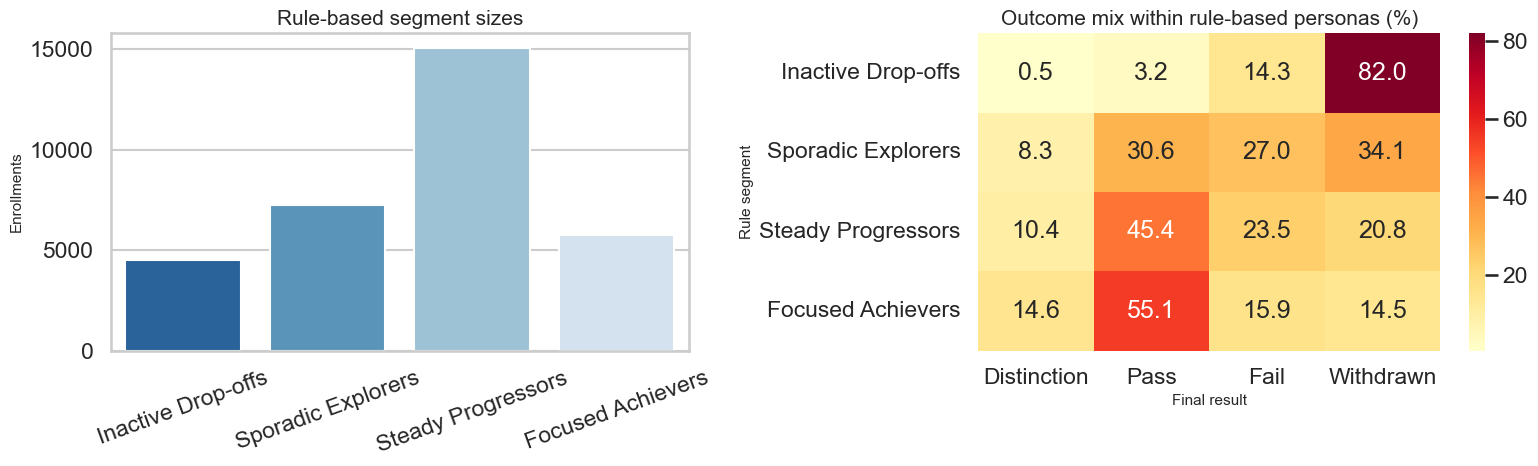

In [4]:
rule_outcome_mix = pd.crosstab(features['rule_segment'], features['final_result']).reindex(index=CLUSTER_ORDER, columns=OUTCOME_ORDER, fill_value=0)
rule_outcome_pct = rule_outcome_mix.div(rule_outcome_mix.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rule_counts = features['rule_segment'].value_counts().reindex(CLUSTER_ORDER)
sns.barplot(x=rule_counts.index, y=rule_counts.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Rule-based segment sizes')
axes[0].set_xlabel('')
axes[0].set_ylabel('Enrollments')
axes[0].tick_params(axis='x', rotation=20)

sns.heatmap(rule_outcome_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Outcome mix within rule-based personas (%)')
axes[1].set_xlabel('Final result')
axes[1].set_ylabel('Rule segment')

plt.tight_layout()


## 3. K-Means model selection

The main segmentation model is a **K-Means clustering** built on the standardized behavioral feature matrix.
To avoid arbitrary cluster count selection, we compare several `k` values using:

- inertia (elbow view)
- silhouette score
- Calinski-Harabasz score
- Davies-Bouldin index

A good project-grade choice should balance metric quality with interpretability.


,k,inertia,silhouette_score,calinski_harabasz,davies_bouldin
0,3,"140,864.071",0.376,"21,408.245",1.099
1,4,"115,555.457",0.394,"19,776.652",1.039
2,5,"97,817.167",0.345,"18,999.105",1.163
3,6,"86,792.077",0.363,"17,957.499",1.160
4,7,"76,556.719",0.365,"17,690.764",1.128


Selected k from the metric comparison: 4


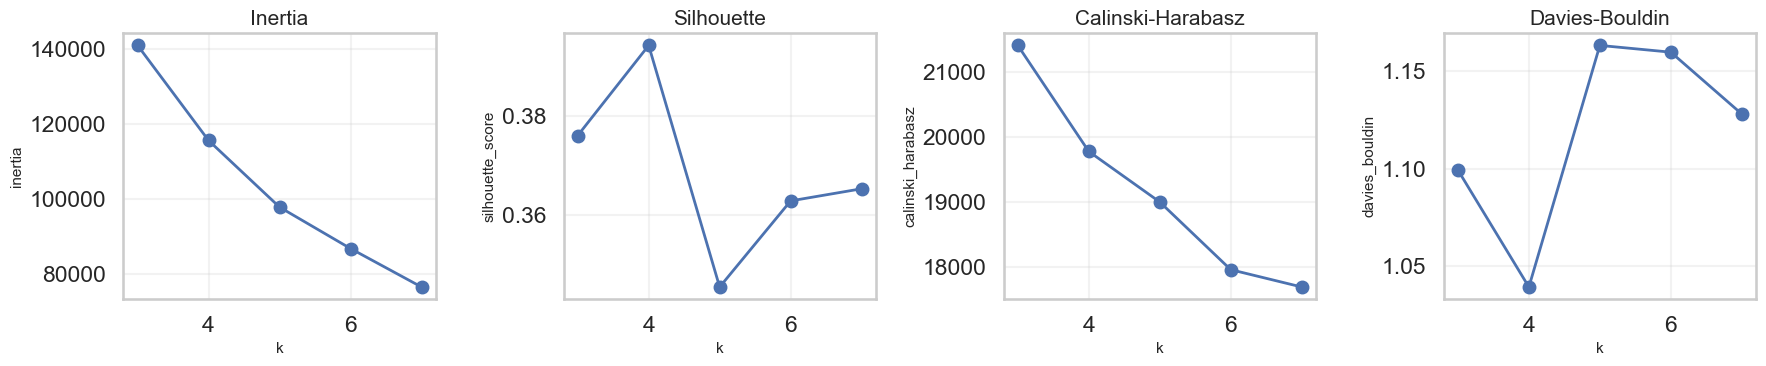

In [5]:
X_seg = segmentation_features[SEG_FEATURES].astype(float)

model_selection_rows = []
for k in range(3, 8):
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X_seg)
    silhouette = silhouette_score(X_seg, labels, sample_size=min(10000, len(X_seg)), random_state=42)
    model_selection_rows.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette_score': silhouette,
        'calinski_harabasz': calinski_harabasz_score(X_seg, labels),
        'davies_bouldin': davies_bouldin_score(X_seg, labels),
    })

model_selection = pd.DataFrame(model_selection_rows)
display(model_selection.round(4))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metric_specs = [
    ('inertia', 'Inertia', False),
    ('silhouette_score', 'Silhouette', True),
    ('calinski_harabasz', 'Calinski-Harabasz', True),
    ('davies_bouldin', 'Davies-Bouldin', False),
]

for ax, (col, title, higher_is_better) in zip(axes, metric_specs):
    ax.plot(model_selection['k'], model_selection[col], marker='o', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel(col)
    ax.grid(alpha=0.25)

best_k = int(model_selection.sort_values(['silhouette_score', 'davies_bouldin'], ascending=[False, True]).iloc[0]['k'])
plt.tight_layout()
print(f'Selected k from the metric comparison: {best_k}')


**Working decision:** use **`k = 4`**.

This choice gives the best overall silhouette in the tested range and, more importantly, yields four clusters that are easy to explain to instructors and managers:

1. a near-silent disengaged group,
2. a low-discipline exploratory group,
3. a broad middle group with sustainable progress,
4. a high-discipline high-performance group.


## 4. Final K-Means segments and interpretation


In [6]:
FINAL_K = 4
cluster_model = KMeans(n_clusters=FINAL_K, n_init=20, random_state=42)
cluster_ids = cluster_model.fit_predict(X_seg)

features['cluster_id'] = cluster_ids
segmentation_features['cluster_id'] = cluster_ids
recommendation_features['cluster_id'] = cluster_ids

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_seg)
features['pca_1'] = pca_coords[:, 0]
features['pca_2'] = pca_coords[:, 1]

cluster_summary = (
    features.groupby('cluster_id')
    .agg(
        enrollments=('id_student', 'size'),
        at_risk_rate=('at_risk', 'mean'),
        median_total_clicks=('total_clicks', 'median'),
        median_active_days=('active_days', 'median'),
        median_early_engagement_ratio=('early_engagement_ratio', 'median'),
        median_avg_score=('avg_score', 'median'),
        median_completion_ratio=('completion_ratio', 'median'),
        median_assessment_discipline=('assessment_discipline', 'median'),
        median_persistence_score=('persistence_score', 'median'),
    )
    .reset_index()
)

inactive_cluster = int(cluster_summary.sort_values(['median_total_clicks', 'median_completion_ratio', 'at_risk_rate'], ascending=[True, True, False]).iloc[0]['cluster_id'])
achiever_cluster = int(cluster_summary.sort_values(['median_completion_ratio', 'median_avg_score', 'median_assessment_discipline'], ascending=[False, False, False]).iloc[0]['cluster_id'])
remaining_clusters = [cid for cid in cluster_summary['cluster_id'] if cid not in {inactive_cluster, achiever_cluster}]
remaining_summary = cluster_summary[cluster_summary['cluster_id'].isin(remaining_clusters)]
sporadic_cluster = int(remaining_summary.sort_values(['median_completion_ratio', 'median_total_clicks', 'at_risk_rate'], ascending=[True, True, False]).iloc[0]['cluster_id'])
steady_cluster = int([cid for cid in cluster_summary['cluster_id'] if cid not in {inactive_cluster, achiever_cluster, sporadic_cluster}][0])

cluster_label_map = {
    inactive_cluster: 'Inactive Drop-offs',
    sporadic_cluster: 'Sporadic Explorers',
    steady_cluster: 'Steady Progressors',
    achiever_cluster: 'Focused Achievers',
}

features['cluster_label'] = features['cluster_id'].map(cluster_label_map)
segmentation_features['cluster_label'] = segmentation_features['cluster_id'].map(cluster_label_map)
recommendation_features['cluster_label'] = recommendation_features['cluster_id'].map(cluster_label_map)

features['cluster_label'] = pd.Categorical(features['cluster_label'], categories=CLUSTER_ORDER, ordered=True)
segmentation_features['cluster_label'] = pd.Categorical(segmentation_features['cluster_label'], categories=CLUSTER_ORDER, ordered=True)
recommendation_features['cluster_label'] = pd.Categorical(recommendation_features['cluster_label'], categories=CLUSTER_ORDER, ordered=True)

cluster_summary['cluster_label'] = cluster_summary['cluster_id'].map(cluster_label_map)
cluster_summary['cluster_label'] = pd.Categorical(cluster_summary['cluster_label'], categories=CLUSTER_ORDER, ordered=True)
cluster_summary = cluster_summary.sort_values('cluster_label').assign(
    share_of_dataset=lambda df: df['enrollments'] / len(features) * 100,
    at_risk_rate=lambda df: df['at_risk_rate'] * 100,
)

display(cluster_summary.round(2))


,cluster_id,enrollments,at_risk_rate,median_total_clicks,median_active_days,median_early_engagement_ratio,median_avg_score,median_completion_ratio,median_assessment_discipline,median_persistence_score,cluster_label,share_of_dataset
0,0,5018,93.080,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Inactive Drop-offs,15.400
3,3,8476,60.820,79.000,5.000,0.590,0.000,0.000,0.000,0.380,Sporadic Explorers,26.010
1,1,17047,39.430,241.000,13.000,0.480,78.000,0.500,0.290,0.480,Steady Progressors,52.300
2,2,2052,32.160,541.000,19.000,0.460,80.000,1.000,0.740,0.640,Focused Achievers,6.300


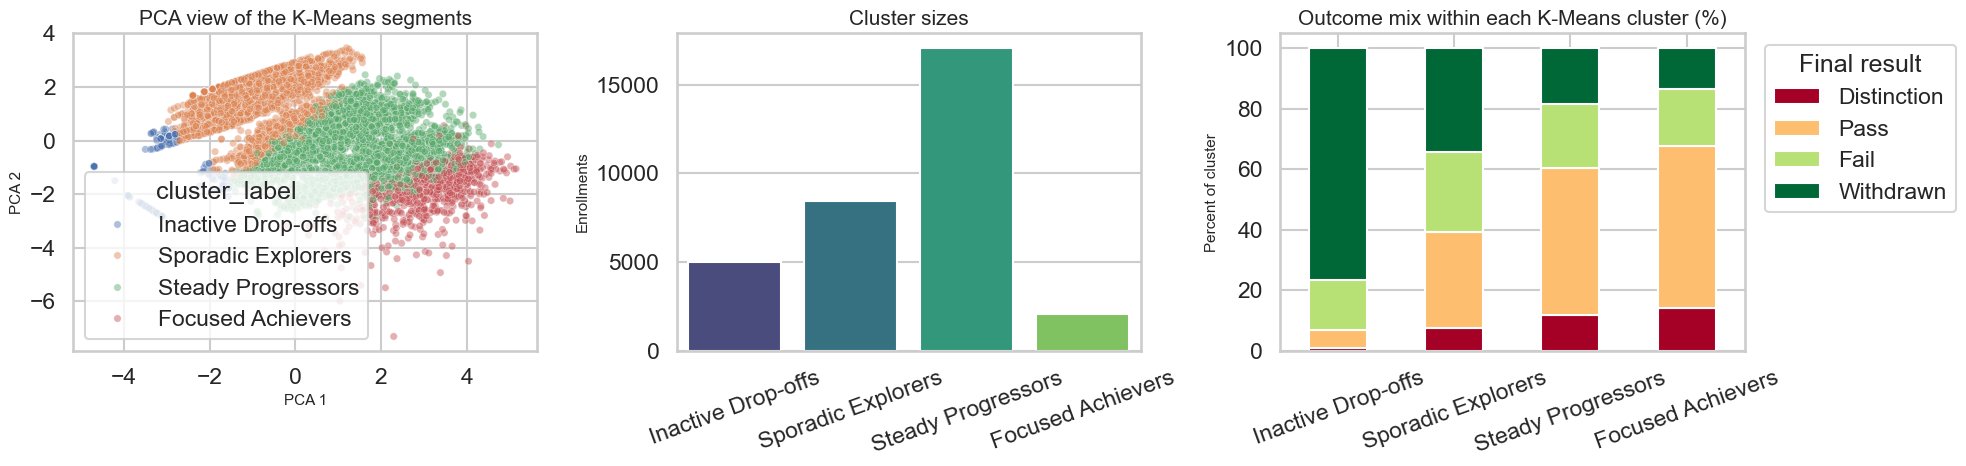

In [7]:
cluster_outcome_pct = pd.crosstab(features['cluster_label'], features['final_result']).reindex(index=CLUSTER_ORDER, columns=OUTCOME_ORDER, fill_value=0)
cluster_outcome_pct = cluster_outcome_pct.div(cluster_outcome_pct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_df = features.sample(min(12000, len(features)), random_state=42)
sns.scatterplot(
    data=plot_df,
    x='pca_1', y='pca_2',
    hue='cluster_label',
    hue_order=CLUSTER_ORDER,
    alpha=0.45,
    s=28,
    ax=axes[0],
)
axes[0].set_title('PCA view of the K-Means segments')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

cluster_counts = features['cluster_label'].value_counts().reindex(CLUSTER_ORDER)
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Cluster sizes')
axes[1].set_xlabel('')
axes[1].set_ylabel('Enrollments')
axes[1].tick_params(axis='x', rotation=20)

cluster_outcome_pct.plot(kind='bar', stacked=True, ax=axes[2], colormap='RdYlGn')
axes[2].set_title('Outcome mix within each K-Means cluster (%)')
axes[2].set_xlabel('')
axes[2].set_ylabel('Percent of cluster')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='Final result', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()


Rule-based vs K-Means alignment (% within each rule segment):


cluster_label,Inactive Drop-offs,Sporadic Explorers,Steady Progressors,Focused Achievers
rule_segment,,,,
Inactive Drop-offs,100.000,0.000,0.000,0.000
Sporadic Explorers,3.700,96.300,0.000,0.000
Steady Progressors,1.400,9.800,83.600,5.200
Focused Achievers,0.000,0.000,77.900,22.100


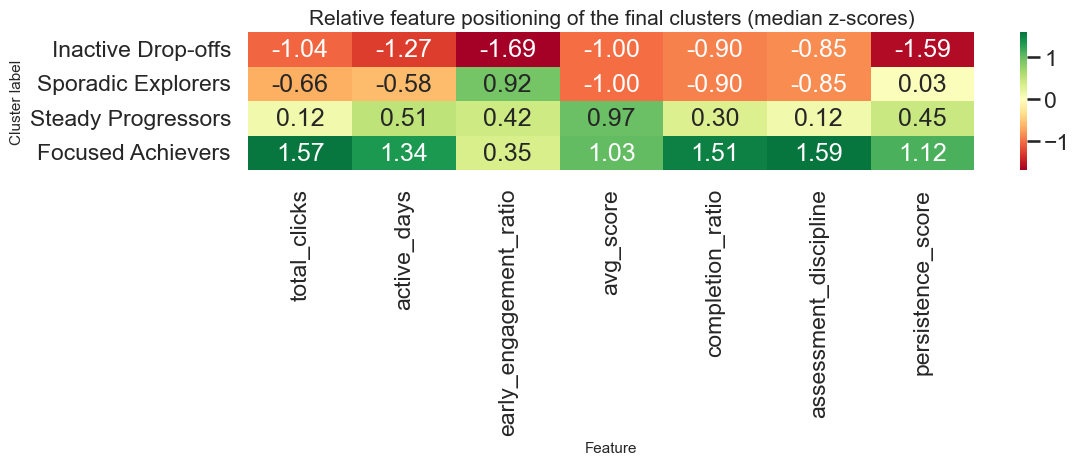

In [8]:
profile_features = [
    'total_clicks',
    'active_days',
    'early_engagement_ratio',
    'avg_score',
    'completion_ratio',
    'assessment_discipline',
    'persistence_score',
]

cluster_profile_medians = (
    features.groupby('cluster_label', observed=True)[profile_features]
    .median()
    .reindex(CLUSTER_ORDER)
)
cluster_profile_z = (cluster_profile_medians - cluster_profile_medians.mean()) / cluster_profile_medians.std(ddof=0)

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile_z, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Relative feature positioning of the final clusters (median z-scores)')
plt.xlabel('Feature')
plt.ylabel('Cluster label')
plt.tight_layout()

rule_vs_kmeans = pd.crosstab(features['rule_segment'], features['cluster_label'], normalize='index').reindex(index=CLUSTER_ORDER, columns=CLUSTER_ORDER, fill_value=0) * 100
print('Rule-based vs K-Means alignment (% within each rule segment):')
display(rule_vs_kmeans.round(1))


## 5. Recommendation logic

The recommendation layer follows the project proposal but keeps the implementation interpretable.
For each enrollment, the notebook compares the learner against **successful peers inside the same K-Means cluster**.

### Score components
- **Peer similarity score**: how close the learner is to the successful prototype in the recommendation feature space
- **Engagement fit score**: how close the learner is to the successful prototype on the engagement-related dimensions only
- **Completion probability proxy**: `1 - learning_risk_index` from notebook 04
- **Accessibility score**: share of recommended activity types that are actually available in the learner's module-presentation

### Final recommendation score

`0.20 * accessibility + 0.30 * peer similarity + 0.25 * engagement fit + 0.25 * completion proxy`

This is a prioritization score for guidance and dashboarding. It is **not** a supervised probability model.


In [9]:
success_prototypes = (
    recommendation_features[recommendation_features['final_result'].isin(SUCCESS_OUTCOMES)]
    .groupby('cluster_label', observed=True)[REC_FEATURES]
    .mean()
    .reindex(CLUSTER_ORDER)
)

display(success_prototypes.round(3))

rec_work = recommendation_features.merge(
    success_prototypes.add_prefix('target_'),
    left_on='cluster_label',
    right_index=True,
    how='left',
)

engagement_cols = ['total_clicks_log', 'early_engagement_ratio', 'engagement_intensity_log', 'persistence_score']
rec_work['engagement_fit_score'] = (
    1 - np.abs(
        rec_work[engagement_cols].to_numpy() - rec_work[[f'target_{col}' for col in engagement_cols]].to_numpy()
    ).mean(axis=1)
).clip(0, 1)

prototype_distance = np.linalg.norm(
    rec_work[REC_FEATURES].to_numpy() - rec_work[[f'target_{col}' for col in REC_FEATURES]].to_numpy(),
    axis=1,
)
rec_work['peer_similarity_score'] = 1 - (prototype_distance / prototype_distance.max())
rec_work['completion_probability_proxy'] = 1 - rec_work['learning_risk_index']

feature_gap_table = rec_work[KEY + ['cluster_label']].copy()
action_gap_features = [
    'completion_ratio',
    'assessment_discipline',
    'avg_score',
    'persistence_score',
    'early_engagement_ratio',
    'total_clicks_log',
    'engagement_intensity_log',
]
for col in action_gap_features:
    feature_gap_table[col] = rec_work[f'target_{col}'] - rec_work[col]

path_map = {
    'completion_ratio': 'Assessment Recovery Path',
    'assessment_discipline': 'Assessment Discipline Path',
    'avg_score': 'Mastery Improvement Path',
    'persistence_score': 'Consistency Building Path',
    'early_engagement_ratio': 'Early Start Path',
    'total_clicks_log': 'Re-Engagement Path',
    'engagement_intensity_log': 'Focused Study Path',
}

action_map = {
    'completion_ratio': 'Submit all available assessments in the first month and avoid missing deadlines.',
    'assessment_discipline': 'Follow a fixed weekly assessment schedule and submit earlier, not at the last minute.',
    'avg_score': 'Prioritize accuracy and revision quality before increasing workload volume.',
    'persistence_score': 'Spread study activity across more days each week instead of short bursts.',
    'early_engagement_ratio': 'Move more of your study activity into the first two weeks of the course.',
    'total_clicks_log': 'Increase total learning activity in the first 30 days with short, regular study sessions.',
    'engagement_intensity_log': 'Use more focused study sessions on the days you are active.',
}
SUSTAIN_ACTIONS = [
    'Maintain the current weekly study rhythm and keep assessment completion high.',
    'Deepen mastery with more self-check quiz work and high-value content review.',
    'Contribute in discussion-oriented activities to consolidate understanding and retention.',
]


def top_gap_bundle(row: pd.Series) -> pd.Series:
    ordered = sorted(action_gap_features, key=lambda col: row[col], reverse=True)
    positive = [col for col in ordered if row[col] > 0.05][:3]
    if not positive:
        positive = ['avg_score', 'persistence_score', 'early_engagement_ratio']
    positive += [None] * (3 - len(positive))
    return pd.Series({
        'gap_feature_1': positive[0],
        'gap_feature_2': positive[1],
        'gap_feature_3': positive[2],
        'recommended_path': path_map[positive[0]],
        'action_1': action_map[positive[0]],
        'action_2': action_map[positive[1]] if positive[1] else None,
        'action_3': action_map[positive[2]] if positive[2] else None,
    })


gap_actions = pd.concat([feature_gap_table[KEY], feature_gap_table.apply(top_gap_bundle, axis=1)], axis=1)

strong_learners = (
    features['at_risk'].eq(0)
    & rec_work['peer_similarity_score'].ge(0.82)
    & rec_work['completion_probability_proxy'].ge(0.50)
    & features['avg_score'].ge(75)
    & features['completion_ratio'].ge(0.50)
)

gap_actions.loc[strong_learners.values, 'recommended_path'] = 'Sustain & Deepen Path'
gap_actions.loc[strong_learners.values, ['gap_feature_1', 'gap_feature_2', 'gap_feature_3']] = ['maintain_strength', 'deepen_mastery', 'peer_discussion']
gap_actions.loc[strong_learners.values, ['action_1', 'action_2', 'action_3']] = SUSTAIN_ACTIONS


,total_clicks_log,early_engagement_ratio,engagement_intensity_log,avg_score,completion_ratio,assessment_discipline,persistence_score,learning_risk_index
cluster_label,,,,,,,,
Inactive Drop-offs,0.081,0.028,0.092,0.172,0.134,0.079,0.197,0.881
Sporadic Explorers,0.531,0.524,0.503,0.034,0.077,0.046,0.435,0.815
Steady Progressors,0.631,0.482,0.547,0.806,0.663,0.378,0.544,0.470
Focused Achievers,0.721,0.475,0.625,0.816,0.956,0.670,0.670,0.373


## 6. Activity-type recommendation profiles

The feature-level path tells us **what kind of intervention a learner needs**.
The activity-type layer tells us **where that intervention should be directed inside the learning platform**.

To keep the recommendation actionable:
- activity preferences are learned from successful learners in each cluster,
- recommendations are constrained to activity types that exist in the learner's current module-presentation.


In [10]:
def build_student_activity_mix(cache_path: Path) -> pd.DataFrame:
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        return cached

    vle_lookup = vle_clean[['id_site', 'activity_type']].drop_duplicates()
    aggregate_frames = []

    for chunk in pd.read_csv(
        PROCESSED / 'student_vle_clean.csv',
        usecols=['id_student', 'code_module', 'code_presentation', 'id_site', 'sum_click'],
        chunksize=1_000_000,
    ):
        merged = chunk.merge(vle_lookup, on='id_site', how='left')
        merged['activity_type'] = merged['activity_type'].fillna('Unknown')
        aggregate_frames.append(
            merged.groupby(KEY + ['activity_type'], as_index=False)['sum_click'].sum()
        )

    student_activity = (
        pd.concat(aggregate_frames, ignore_index=True)
        .groupby(KEY + ['activity_type'], as_index=False)['sum_click']
        .sum()
    )
    student_activity['activity_share'] = student_activity['sum_click'] / student_activity.groupby(KEY)['sum_click'].transform('sum')
    student_activity.to_csv(cache_path, index=False)
    return student_activity


student_activity_cache = PROCESSED / '_nb05_student_activity_mix.csv'
student_activity_mix = build_student_activity_mix(student_activity_cache)
student_activity_mix['activity_label'] = student_activity_mix['activity_type'].map(humanize_activity_type)

assignment_cols = KEY + ['cluster_label', 'final_result', 'at_risk']
student_activity_mix = student_activity_mix.merge(features[assignment_cols], on=KEY, how='left')

cluster_success_activity = (
    student_activity_mix[student_activity_mix['final_result'].isin(SUCCESS_OUTCOMES)]
    .groupby(['cluster_label', 'activity_type', 'activity_label'], observed=True, as_index=False)['sum_click']
    .sum()
)
cluster_success_activity['cluster_activity_share'] = (
    cluster_success_activity['sum_click'] /
    cluster_success_activity.groupby('cluster_label', observed=True)['sum_click'].transform('sum')
)
cluster_success_activity = cluster_success_activity.sort_values(['cluster_label', 'cluster_activity_share'], ascending=[True, False])

display(cluster_success_activity.groupby('cluster_label', observed=True).head(8).round(4))


,cluster_label,activity_type,activity_label,sum_click,cluster_activity_share
9,Inactive Drop-offs,oucontent,Core learning content,55101,0.348
14,Inactive Drop-offs,quiz,Self-check quizzes,38885,0.246
6,Inactive Drop-offs,homepage,Course homepage,26700,0.169
4,Inactive Drop-offs,forumng,Discussion forum,19380,0.123
16,Inactive Drop-offs,subpage,Structured topic pages,8968,0.057
15,Inactive Drop-offs,resource,Downloadable resources,5582,0.035
11,Inactive Drop-offs,ouwiki,Collaborative wiki,1379,0.009
17,Inactive Drop-offs,url,External links,981,0.006
27,Sporadic Explorers,oucontent,Core learning content,1623738,0.381
22,Sporadic Explorers,forumng,Discussion forum,757222,0.177


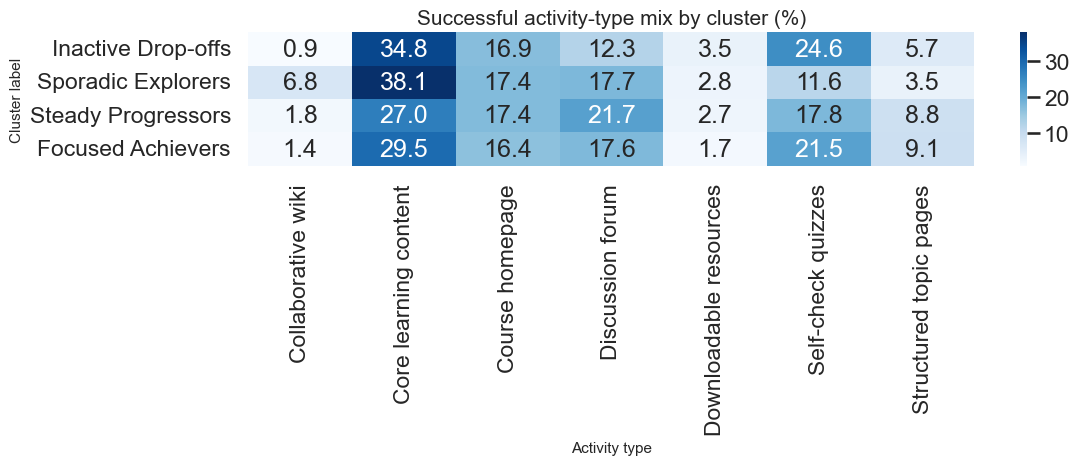

In [11]:
top_activity_types = (
    cluster_success_activity.groupby('activity_label', observed=True)['cluster_activity_share']
    .mean()
    .sort_values(ascending=False)
    .head(7)
    .index
)

activity_heatmap = (
    cluster_success_activity[cluster_success_activity['activity_label'].isin(top_activity_types)]
    .pivot(index='cluster_label', columns='activity_label', values='cluster_activity_share')
    .reindex(CLUSTER_ORDER)
    .fillna(0)
)

plt.figure(figsize=(12, 5))
sns.heatmap(activity_heatmap * 100, annot=True, fmt='.1f', cmap='Blues')
plt.title('Successful activity-type mix by cluster (%)')
plt.xlabel('Activity type')
plt.ylabel('Cluster label')
plt.tight_layout()


## 7. Enrollment-level personalized learning paths

The final recommendation output combines:
- segment identity,
- rule-based persona,
- recommendation score,
- recommended path,
- the three strongest action suggestions,
- the three most relevant activity types to emphasize.


In [12]:
module_activity_availability = (
    vle_clean[['code_module', 'code_presentation', 'activity_type']]
    .drop_duplicates()
    .assign(is_available=1)
)

successful_top_activity = (
    cluster_success_activity.sort_values(['cluster_label', 'cluster_activity_share'], ascending=[True, False])
    .groupby('cluster_label', observed=True)
    .head(5)
    [['cluster_label', 'activity_type', 'activity_label', 'cluster_activity_share']]
)

activity_candidates = (
    features[KEY + ['cluster_label']]
    .merge(successful_top_activity, on='cluster_label', how='left')
    .merge(module_activity_availability, on=['code_module', 'code_presentation', 'activity_type'], how='left')
)
activity_candidates['is_available'] = activity_candidates['is_available'].fillna(0)
activity_candidates = activity_candidates[activity_candidates['is_available'].eq(1)].copy()

activity_candidates = activity_candidates.merge(
    student_activity_mix[KEY + ['activity_type', 'activity_share']],
    on=KEY + ['activity_type'],
    how='left',
)
activity_candidates['activity_share'] = activity_candidates['activity_share'].fillna(0)
activity_candidates['share_gap'] = activity_candidates['cluster_activity_share'] - activity_candidates['activity_share']
activity_candidates = activity_candidates.sort_values(KEY + ['share_gap'], ascending=[True, True, True, False])


def top_activity_bundle(group: pd.DataFrame) -> pd.Series:
    top = group.head(3)
    labels = top['activity_label'].tolist()
    raw_codes = top['activity_type'].tolist()
    labels += [None] * (3 - len(labels))
    raw_codes += [None] * (3 - len(raw_codes))
    return pd.Series({
        'activity_type_1': raw_codes[0],
        'activity_type_2': raw_codes[1],
        'activity_type_3': raw_codes[2],
        'activity_recommendation_1': labels[0],
        'activity_recommendation_2': labels[1],
        'activity_recommendation_3': labels[2],
        'accessibility_score': group['is_available'].mean(),
    })


activity_recommendations = (
    activity_candidates.groupby(KEY, observed=True)
    .apply(top_activity_bundle)
    .reset_index()
)

personalized_recommendations = (
    features[
        KEY + [
            'final_result', 'at_risk', 'rule_segment', 'cluster_id', 'cluster_label',
            'total_clicks', 'active_days', 'avg_score', 'completion_ratio',
            'assessment_discipline', 'persistence_score',
        ]
    ]
    .merge(
        rec_work[KEY + ['peer_similarity_score', 'engagement_fit_score', 'completion_probability_proxy']],
        on=KEY,
        how='left',
    )
    .merge(gap_actions, on=KEY, how='left')
    .merge(activity_recommendations, on=KEY, how='left')
)

personalized_recommendations['accessibility_score'] = personalized_recommendations['accessibility_score'].fillna(0)
personalized_recommendations['recommendation_score'] = (
    100 * (
        0.20 * personalized_recommendations['accessibility_score']
        + 0.30 * personalized_recommendations['peer_similarity_score']
        + 0.25 * personalized_recommendations['engagement_fit_score']
        + 0.25 * personalized_recommendations['completion_probability_proxy']
    )
).round(1)

personalized_recommendations['rule_segment'] = pd.Categorical(personalized_recommendations['rule_segment'], categories=CLUSTER_ORDER, ordered=True)
personalized_recommendations['cluster_label'] = pd.Categorical(personalized_recommendations['cluster_label'], categories=CLUSTER_ORDER, ordered=True)

recommendation_summary = (
    personalized_recommendations.groupby(['cluster_label', 'recommended_path'], observed=True)
    .agg(
        enrollments=('id_student', 'size'),
        avg_recommendation_score=('recommendation_score', 'mean'),
        avg_peer_similarity=('peer_similarity_score', 'mean'),
        avg_completion_proxy=('completion_probability_proxy', 'mean'),
    )
    .reset_index()
    .sort_values(['cluster_label', 'enrollments'], ascending=[True, False])
)

display(recommendation_summary.round(2))


,cluster_label,recommended_path,enrollments,avg_recommendation_score,avg_peer_similarity,avg_completion_proxy
1,Inactive Drop-offs,Consistency Building Path,4634,65.280,0.760,0.010
2,Inactive Drop-offs,Mastery Improvement Path,383,61.590,0.530,0.200
0,Inactive Drop-offs,Assessment Recovery Path,1,69.000,0.690,0.230
5,Sporadic Explorers,Early Start Path,2821,63.620,0.650,0.160
4,Sporadic Explorers,Consistency Building Path,2298,66.000,0.700,0.150
8,Sporadic Explorers,Re-Engagement Path,1454,58.920,0.480,0.310
3,Sporadic Explorers,Assessment Recovery Path,1304,68.910,0.730,0.230
6,Sporadic Explorers,Focused Study Path,500,67.530,0.710,0.200
7,Sporadic Explorers,Mastery Improvement Path,99,68.690,0.640,0.270
9,Steady Progressors,Assessment Recovery Path,4295,75.660,0.680,0.520


Representative recommendation examples:


,id_student,code_module,code_presentation,cluster_label,final_result,recommended_path,recommendation_score,action_1,action_2,activity_recommendation_1,activity_recommendation_2
4559,1413989,BBB,2013J,Inactive Drop-offs,Withdrawn,Mastery Improvement Path,69.300,Prioritize accuracy and revision quality befor...,Submit all available assessments in the first ...,Core learning content,Self-check quizzes
14325,2526483,DDD,2013B,Inactive Drop-offs,Fail,Mastery Improvement Path,69.300,Prioritize accuracy and revision quality befor...,Submit all available assessments in the first ...,Core learning content,Course homepage
30301,571768,GGG,2013J,Inactive Drop-offs,Fail,Consistency Building Path,69.100,Spread study activity across more days each we...,Submit all available assessments in the first ...,Core learning content,Discussion forum
32123,645730,GGG,2014J,Sporadic Explorers,Pass,Assessment Recovery Path,76.700,Submit all available assessments in the first ...,None,Discussion forum,Core learning content
22713,437246,FFF,2013B,Sporadic Explorers,Fail,Assessment Recovery Path,76.300,Submit all available assessments in the first ...,None,Core learning content,Self-check quizzes
30647,595335,GGG,2013J,Sporadic Explorers,Distinction,Assessment Recovery Path,76.300,Submit all available assessments in the first ...,None,Core learning content,Self-check quizzes
9393,555008,CCC,2014B,Steady Progressors,Pass,Sustain & Deepen Path,85.300,Maintain the current weekly study rhythm and k...,Deepen mastery with more self-check quiz work ...,Core learning content,Discussion forum
12192,645124,CCC,2014J,Steady Progressors,Distinction,Sustain & Deepen Path,85.300,Maintain the current weekly study rhythm and k...,Deepen mastery with more self-check quiz work ...,Core learning content,Discussion forum
10952,437968,CCC,2014J,Steady Progressors,Fail,Mastery Improvement Path,85.100,Prioritize accuracy and revision quality befor...,Spread study activity across more days each we...,Core learning content,Discussion forum
24153,319578,FFF,2013J,Focused Achievers,Pass,Sustain & Deepen Path,88.600,Maintain the current weekly study rhythm and k...,Deepen mastery with more self-check quiz work ...,Discussion forum,Self-check quizzes


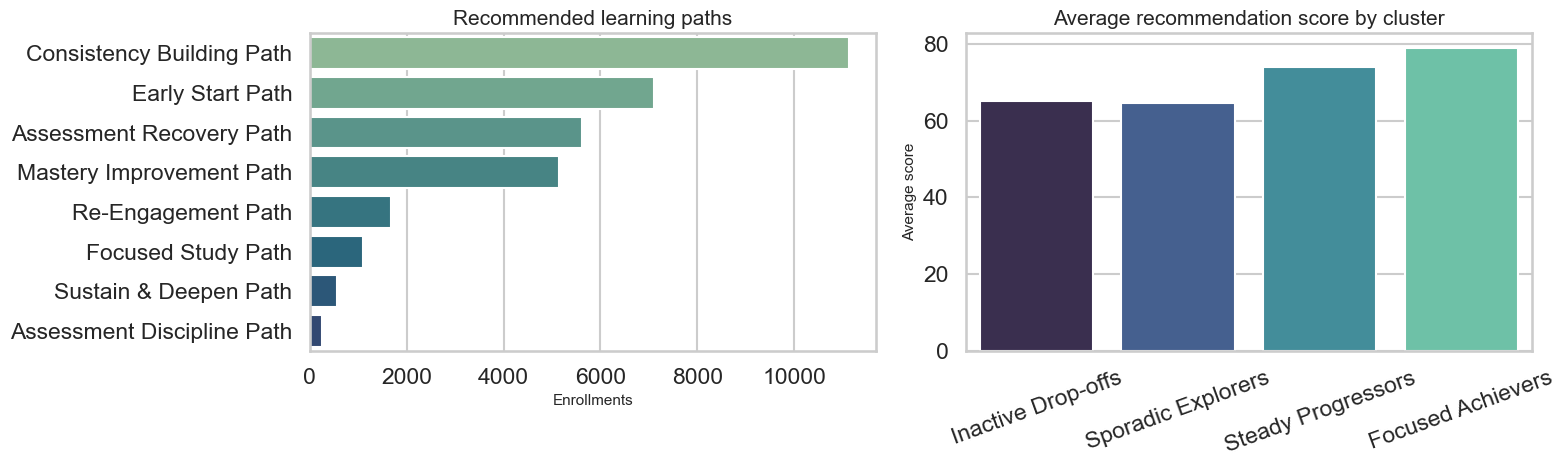

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

path_counts = personalized_recommendations['recommended_path'].value_counts().sort_values(ascending=False)
sns.barplot(x=path_counts.values, y=path_counts.index, ax=axes[0], palette='crest')
axes[0].set_title('Recommended learning paths')
axes[0].set_xlabel('Enrollments')
axes[0].set_ylabel('')

score_by_cluster = personalized_recommendations.groupby('cluster_label', observed=True)['recommendation_score'].mean().reindex(CLUSTER_ORDER)
sns.barplot(x=score_by_cluster.index, y=score_by_cluster.values, ax=axes[1], palette='mako')
axes[1].set_title('Average recommendation score by cluster')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average score')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

sample_recommendations = (
    personalized_recommendations
    .sort_values(['cluster_label', 'recommendation_score'], ascending=[True, False])
    .groupby('cluster_label', observed=True)
    .head(3)
    [[
        'id_student', 'code_module', 'code_presentation', 'cluster_label', 'final_result',
        'recommended_path', 'recommendation_score',
        'action_1', 'action_2', 'activity_recommendation_1', 'activity_recommendation_2'
    ]]
)

print('Representative recommendation examples:')
display(sample_recommendations)


## 8. Export outputs for reporting and Power BI

The notebook exports both a lean segment table and a richer recommendation table.
The recommendation table is the most useful artifact for dashboarding because it already contains:
- segment identity,
- behavioral context,
- path label,
- score,
- actions,
- activity recommendations.


In [14]:
segment_assignments = features[
    KEY + ['final_result', 'at_risk', 'rule_segment', 'cluster_id', 'cluster_label', 'pca_1', 'pca_2']
].copy()

cluster_profiles = cluster_summary.copy()
cluster_success_activity_profile = cluster_success_activity.copy()
recommendation_dashboard_summary = recommendation_summary.copy()

segment_assignments.to_csv(PROCESSED / 'segment_assignments.csv', index=False)
cluster_profiles.to_csv(PROCESSED / 'cluster_profiles.csv', index=False)
cluster_success_activity_profile.to_csv(PROCESSED / 'cluster_success_activity_profile.csv', index=False)
personalized_recommendations.to_csv(PROCESSED / 'personalized_learning_paths.csv', index=False)
recommendation_dashboard_summary.to_csv(PROCESSED / 'recommendation_dashboard_summary.csv', index=False)

print('Saved outputs:')
print(f"  segment_assignments.csv               -> {segment_assignments.shape}")
print(f"  cluster_profiles.csv                 -> {cluster_profiles.shape}")
print(f"  cluster_success_activity_profile.csv -> {cluster_success_activity_profile.shape}")
print(f"  personalized_learning_paths.csv      -> {personalized_recommendations.shape}")
print(f"  recommendation_dashboard_summary.csv -> {recommendation_dashboard_summary.shape}")


Saved outputs:
  segment_assignments.csv               -> (32593, 10)
  cluster_profiles.csv                 -> (4, 12)
  cluster_success_activity_profile.csv -> (74, 5)
  personalized_learning_paths.csv      -> (32593, 32)
  recommendation_dashboard_summary.csv -> (24, 6)


## 9. Conclusion and handoff

### What notebook 05 establishes
1. The **rule-based segmentation** provides an interpretable baseline aligned with the project story.
2. The **K-Means solution with `k = 4`** produces four stable and business-meaningful learner segments.
3. The final segments are not only descriptive; they support **actionable personalized learning paths** tied to successful peer behavior.
4. Recommendations combine **feature gaps** and **activity-type emphasis**, which makes the output directly useful for dashboards and intervention design.

### How this supports notebook 06
Notebook 06 can now focus on supervised at-risk modeling while using the segmentation results for:
- subgroup interpretation,
- cluster-specific business discussion,
- post-model intervention design.

The recommendation score in this notebook is a prioritization device, not a classifier. Notebook 06 should therefore remain the place where predictive model quality is evaluated formally with recall, precision, F1, and ROC-AUC.
